# Construction-Related Incidents Analysis

In [1]:
import pandas as pd
import seaborn as sea
import geopandas as geo
import matplotlib.pyplot as plt

sea.set_theme(
    style='darkgrid',
    rc={
        'figure.facecolor': 'black',
        'axes.facecolor': 'black',
        'text.color': 'white',
        'axes.labelcolor': 'white',
        'xtick.color': 'white',
        'ytick.color': 'white'
    }
)

accent_color = '#4DABF7'

In [2]:
raw_data = pd.read_csv('Construction-Related_Incidents_20260713.csv')
raw_data.head()

,BIN,Accident Report ID,Incident Date,Record Type Description,Check2 Description,Fatality,Injury,House Number,Street Name,Borough,Block,Lot,Postcode,Latitude,Longitude,Community Board,Council District,BBL,Census Tract (2020),Neighborhood Tabulation Area (NTA) (2020)
0,1034211.0,43977,11/19/2024,Incident,Other Construction Related,0,0,520,5 AVENUE,Manhattan,1259.0,35.0,10036.0,40.754421,-73.980213,105.0,4.0,1.012590e+09,96.0,MN0502
1,1060875.0,43984,11/21/2024,Incident,Other Construction Related,0,0,2855,FREDERICK DOUGLAS BOULEVARD,Manhattan,2046.0,63.0,10039.0,40.827410,-73.938587,110.0,9.0,1.020460e+09,23502.0,MN1002
2,3124075.0,45118,10/07/2025,Incident,Scaffold/Shoring Installations,0,0,23,OCEAN PARKWAY,Brooklyn,5322.0,4.0,11218.0,40.650467,-73.973610,307.0,40.0,3.053220e+09,50401.0,BK0701
3,1091801.0,44113,12/30/2024,Accident,Mechanical Construction Equipment,0,1,439,WEST 36 STREET,Manhattan,734.0,10.0,10018.0,40.755430,-73.997152,104.0,3.0,1.007340e+09,111.0,MN0401
4,2130685.0,43974,11/14/2024,Accident,Other Construction Related,0,1,221 D,MANIDA STREET,Bronx,2777.0,100.0,10474.0,40.805223,-73.885975,202.0,17.0,2.027770e+09,9302.0,BX0201


## Explore the data

In [3]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1321 entries, 0 to 1320
Data columns (total 20 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   BIN                                        1318 non-null   float64
 1   Accident Report ID                         1321 non-null   int64  
 2   Incident Date                              1321 non-null   str    
 3   Record Type Description                    1321 non-null   str    
 4   Check2 Description                         1320 non-null   str    
 5   Fatality                                   1321 non-null   int64  
 6   Injury                                     1321 non-null   int64  
 7   House Number                               1321 non-null   str    
 8   Street Name                                1321 non-null   str    
 9   Borough                                    1321 non-null   str    
 10  Block                              

In [4]:
raw_data['Check2 Description'].value_counts()

Check2 Description
Worker Fell                          499
Other Construction Related           478
Material Failure (Fell)              145
Mechanical Construction Equipment     97
Scaffold/Shoring Installations        58
Excavation/Soil Work                  43
Name: count, dtype: int64

## Check "Other Construction Related" records

In [5]:
other_construction = raw_data[
    raw_data['Check2 Description'] == 'Other Construction Related'
]

other_construction.head()

,BIN,Accident Report ID,Incident Date,Record Type Description,Check2 Description,Fatality,Injury,House Number,Street Name,Borough,Block,Lot,Postcode,Latitude,Longitude,Community Board,Council District,BBL,Census Tract (2020),Neighborhood Tabulation Area (NTA) (2020)
0,1034211.0,43977,11/19/2024,Incident,Other Construction Related,0,0,520,5 AVENUE,Manhattan,1259.0,35.0,10036.0,40.754421,-73.980213,105.0,4.0,1.012590e+09,96.0,MN0502
1,1060875.0,43984,11/21/2024,Incident,Other Construction Related,0,0,2855,FREDERICK DOUGLAS BOULEVARD,Manhattan,2046.0,63.0,10039.0,40.827410,-73.938587,110.0,9.0,1.020460e+09,23502.0,MN1002
4,2130685.0,43974,11/14/2024,Accident,Other Construction Related,0,1,221 D,MANIDA STREET,Bronx,2777.0,100.0,10474.0,40.805223,-73.885975,202.0,17.0,2.027770e+09,9302.0,BX0201
7,3428561.0,43920,11/04/2024,Accident,Other Construction Related,0,1,1215,FULTON STREET,Brooklyn,1842.0,15.0,11216.0,40.680609,-73.952845,303.0,36.0,3.018420e+09,245.0,BK0301
10,1091788.0,45119,10/08/2025,Accident,Other Construction Related,0,1,255,EAST 39 STREET,Manhattan,920.0,28.0,10016.0,40.748247,-73.974347,106.0,4.0,NaN,88.0,MN0603


In [6]:
other_construction['Borough'].value_counts()

Borough
Manhattan        180
Brooklyn         175
Queens            63
Bronx             51
Staten Island      9
Name: count, dtype: int64

In [7]:
other_construction[['Fatality', 'Injury']].sum()

Fatality      3
Injury      312
dtype: int64

## Injury counts by borough

In [8]:
borough_injuries = raw_data.groupby('Borough')['Injury'].sum().reset_index()

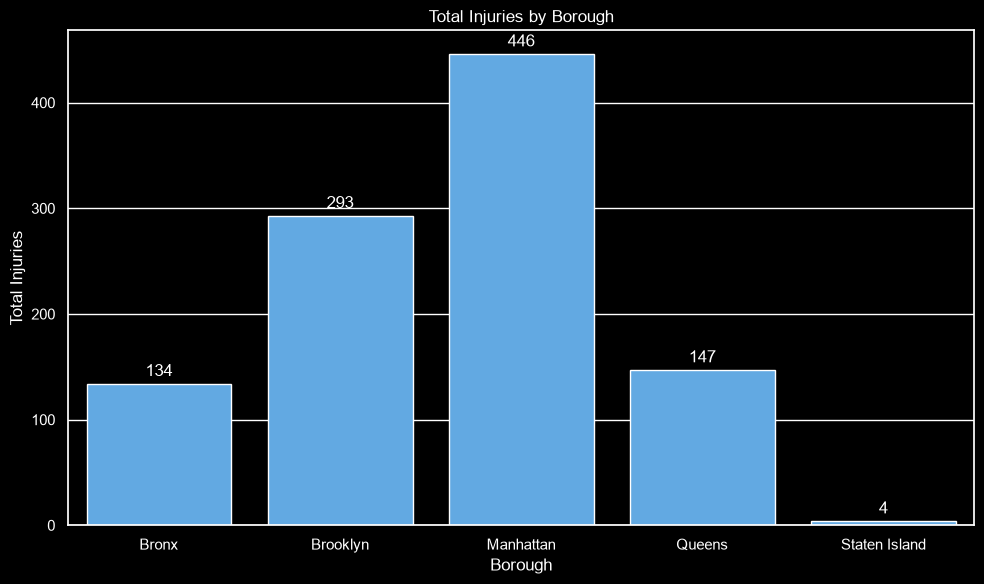

In [9]:
plt.figure(figsize=(10, 6))
ax = sea.barplot(
    data=borough_injuries,
    x='Borough',
    y='Injury',
    color=accent_color
)
ax.set(
    title='Total Injuries by Borough',
    xlabel='Borough',
    ylabel='Total Injuries'
)
ax.bar_label(ax.containers[0], padding=3)
plt.tight_layout()
plt.show()

## Accident dates

In [10]:
raw_data['Incident Date'] = pd.to_datetime(raw_data['Incident Date'])

In [11]:
raw_data['Month'] = raw_data['Incident Date'].dt.month_name()

In [12]:
accidents = raw_data[
    raw_data['Record Type Description'] == 'Accident'
].copy()

accidents.head()

,BIN,Accident Report ID,Incident Date,Record Type Description,Check2 Description,Fatality,Injury,House Number,Street Name,Borough,...,Lot,Postcode,Latitude,Longitude,Community Board,Council District,BBL,Census Tract (2020),Neighborhood Tabulation Area (NTA) (2020),Month
3,1091801.0,44113,2024-12-30,Accident,Mechanical Construction Equipment,0,1,439,WEST 36 STREET,Manhattan,...,10.0,10018.0,40.755430,-73.997152,104.0,3.0,1.007340e+09,111.0,MN0401,December
4,2130685.0,43974,2024-11-14,Accident,Other Construction Related,0,1,221 D,MANIDA STREET,Bronx,...,100.0,10474.0,40.805223,-73.885975,202.0,17.0,2.027770e+09,9302.0,BX0201,November
5,3429247.0,43925,2024-11-05,Accident,Worker Fell,0,1,487,4 AVENUE,Brooklyn,...,7.0,11215.0,40.668453,-73.990289,306.0,38.0,3.010280e+09,139.0,BK0602,November
6,4855669.0,44747,2025-06-27,Accident,Excavation/Soil Work,0,1,133-45,39 AVENUE,Queens,...,59.0,11354.0,40.759123,-73.834147,407.0,20.0,NaN,871.0,QN0707,June
7,3428561.0,43920,2024-11-04,Accident,Other Construction Related,0,1,1215,FULTON STREET,Brooklyn,...,15.0,11216.0,40.680609,-73.952845,303.0,36.0,3.018420e+09,245.0,BK0301,November


In [13]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

## Total accidents by month

In [14]:
accidents_by_month = accidents.groupby('Month')['Accident Report ID'].count()
accidents_by_month = accidents_by_month[month_order]
accidents_by_month = accidents_by_month.reset_index()
accidents_by_month

,Month,Accident Report ID
0,January,99
1,February,85
2,March,104
3,April,104
4,May,99
5,June,109
6,July,85
7,August,66
8,September,54
9,October,55


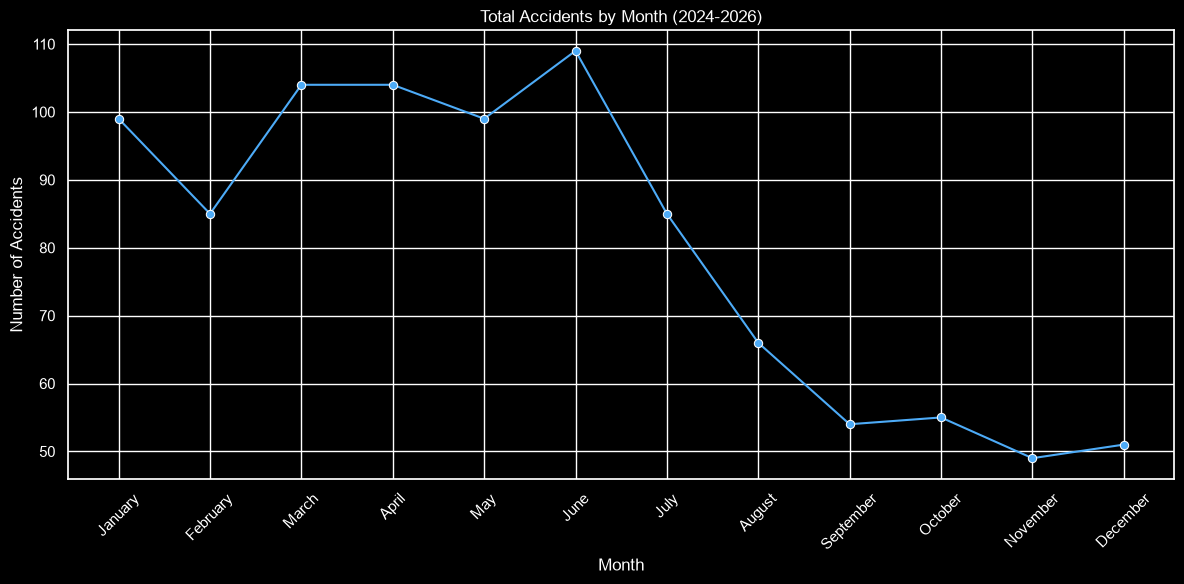

In [15]:
plt.figure(figsize=(12, 6))
ax = sea.lineplot(
    data=accidents_by_month,
    x='Month',
    y='Accident Report ID',
    marker='o',
    color=accent_color
)
ax.set(
    title='Total Accidents by Month (2024-2026)',
    xlabel='Month',
    ylabel='Number of Accidents'
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Accident types by month

In [16]:
accident_types = pd.crosstab(
    accidents['Check2 Description'],
    accidents['Month']
)

accident_types = accident_types[month_order]

In [17]:
accident_types.loc['Total'] = accident_types.sum()

accident_types.columns = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

accident_types

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Check2 Description,,,,,,,,,,,,
Excavation/Soil Work,2,2,0,1,1,1,1,2,1,0,0,1
Material Failure (Fell),8,12,18,11,6,8,8,2,5,8,5,5
Mechanical Construction Equipment,11,10,6,7,10,8,2,2,2,4,3,3
Other Construction Related,23,20,31,35,28,37,25,23,16,15,12,17
Scaffold/Shoring Installations,1,1,1,5,1,1,2,2,2,1,1,1
Worker Fell,54,40,48,45,53,54,47,35,28,27,28,24
Total,99,85,104,104,99,109,85,66,54,55,49,51


In [18]:
type_counts = accident_types.drop('Total')
max_count = type_counts.max().max()

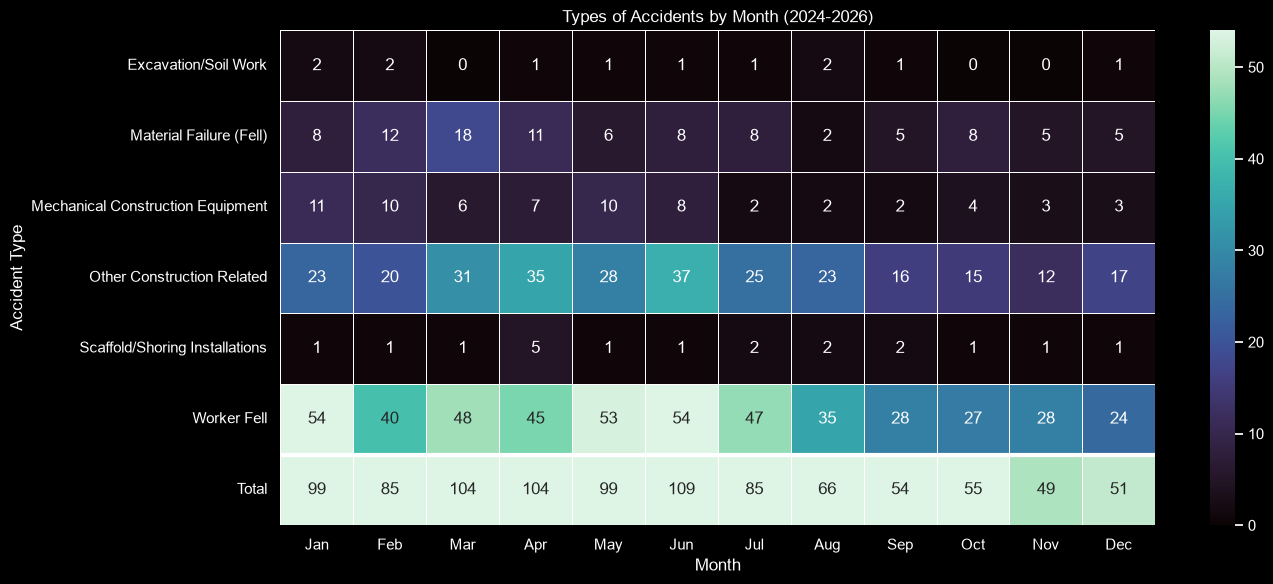

In [19]:
plt.figure(figsize=(14, 6))
ax = sea.heatmap(
    accident_types,
    annot=True,
    fmt='g',
    cmap='mako',
    vmax=max_count,
    linewidths=0.5
)
ax.hlines(6, 0, 12, colors='white', linewidths=3)
ax.set(
    title='Types of Accidents by Month (2024-2026)',
    xlabel='Month',
    ylabel='Accident Type'
)
plt.tight_layout()
plt.show()

## Worker falls compared with other accidents

In [20]:
map_data = accidents.dropna(subset=['Latitude', 'Longitude']).copy()
map_data['Accident Group'] = 'Other'
map_data.loc[
    map_data['Check2 Description'] == 'Worker Fell',
    'Accident Group'
] = 'Worker Fell'
map_colors = {
    'Other': '#4DABF7',
    'Worker Fell': '#FF6B6B'
}
map_url = 'https://data.cityofnewyork.us/resource/gthc-hcne.geojson'
boroughs = geo.read_file(map_url)

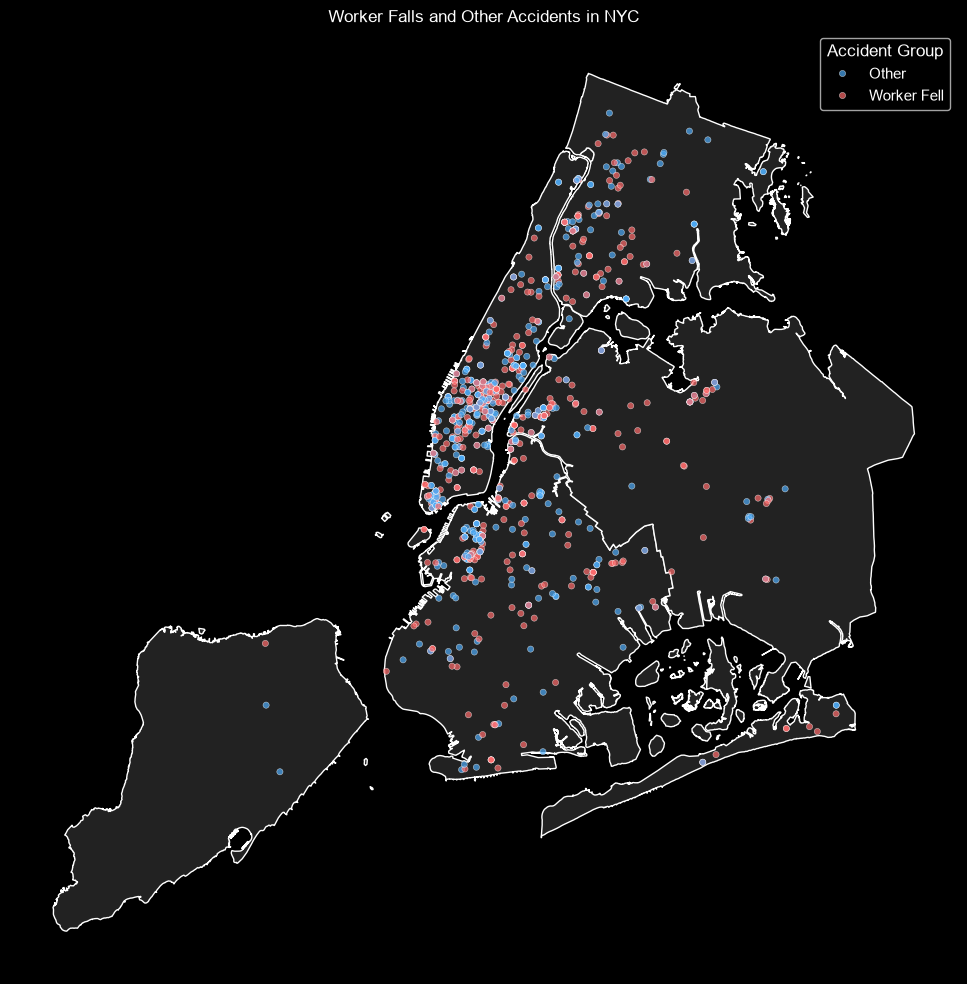

In [21]:
fig, ax = plt.subplots(figsize=(10, 10))
boroughs.plot(
    ax=ax,
    color='#222222',
    edgecolor='white'
)
sea.scatterplot(
    data=map_data,
    x='Longitude',
    y='Latitude',
    hue='Accident Group',
    palette=map_colors,
    alpha=0.7,
    s=20,
    ax=ax
)
plt.title('Worker Falls and Other Accidents in NYC')
plt.axis('off')
plt.tight_layout()
plt.show()

## Analysis

The city should prioritize funding for fall-prevention, as worker falls are the most common type of construction-related incident. Between 2024 and 2026, there were 976 recorded construction accidents and incidents, of which 483 (nearly half) involved a worker falling. Although the fatality rate for worker falls is relatively low at approximately 2.5%, the high number of these incidents resulted in the greatest number of deaths overall. Worker falls accounted for 12 fatalities, compared with only 2–3 deaths each from other major incident categories, such as mechanical construction equipment, material failure, and excavation or soil work.

The city should also examine the seasonal pattern of construction accidents. The line graph shows that from January through July, the number of incidents remained relatively steady at around 90 accidents per month. However, accidents dropped to approximately 65 in August before leveling off at around 50 incidents per month for the remainder of the year. The dataset does not provide enough information to determine the cause of this decline but if the city were to implement policies in an attempt to combat the high number of fall related accidents, they should be done in December/January in preparation for the surge in accidents.